# File 4 — Lifestyle Report

Professor-facing summary of the subject's **lifestyle**, built from File 3's outputs in
`results/lifestyle_construction/`. Replaces the old anomaly audit (ROC/PR/F1). **Descriptive only** —
no anomaly or health claims. Run File 3 (`03_lifestyle_construction.ipynb`) first.

## 1. Load lifestyle artifacts

In [1]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = r"C:\Project\Apple Health Data"
LR = os.path.join(ROOT, "results", "lifestyle_construction")

emb = pd.read_parquet(os.path.join(LR, "day_embeddings.parquet"))
nodes = pd.read_csv(os.path.join(LR, "lifestyle_kg_nodes.csv"))
edges = pd.read_csv(os.path.join(LR, "lifestyle_kg_edges.csv"))
lmap = json.load(open(os.path.join(LR, "lifestyle_map.json")))
evalp = pd.read_csv(os.path.join(LR, "l1_proxy_eval.csv"))
emb["date"] = pd.to_datetime(emb["date"])
print(f"days: {len(emb):,} | lifestyle states: {len(nodes)} | KG edges: {len(edges)}")

days: 1,761 | lifestyle states: 3 | KG edges: 9


## 2. Lifestyle states — *what kind of days this person has*

Each state is a data-derived cluster of days; the name is a rule descriptor over its measured
attributes (median HR, weekday/workout fraction, wear, dominant month).

In [2]:
show = nodes[["state", "name", "n_days", "median_hr", "weekday_frac",
              "workout_day_frac", "median_wear_slots", "top_month"]]
print(show.to_string(index=False))
print("\nstate distribution (days):", lmap["state_distribution"])
print("subject priors:", {k: v for k, v in lmap.get("subject_priors", {}).items()
                          if not k.endswith("_detail")})

 state               name  n_days  median_hr  weekday_frac  workout_day_frac  median_wear_slots  top_month
     0 chilly_winter_rest     683       85.8          0.73              0.07                 59          7
     1 mild_autumn_active     820       86.6          0.71              0.15                 58          3
     2    hot_summer_peak     258       87.5          0.71              0.14                 58          1

state distribution (days): {'mild_autumn_active': 820, 'chilly_winter_rest': 683, 'hot_summer_peak': 258}
subject priors: {'age_band': '40_49', 'sex': 'male', 'fitness_level': 'recreational', 'home_climate': 'temperate', 'occupation': 'unknown', 'heart_health': 'unknown', 'sleep': 'unknown', 'health_conditions': 'none', 'dataset_domain': 'consumer_wearable', 'global_prior_active': False}


## 3. Weekly & seasonal rhythm

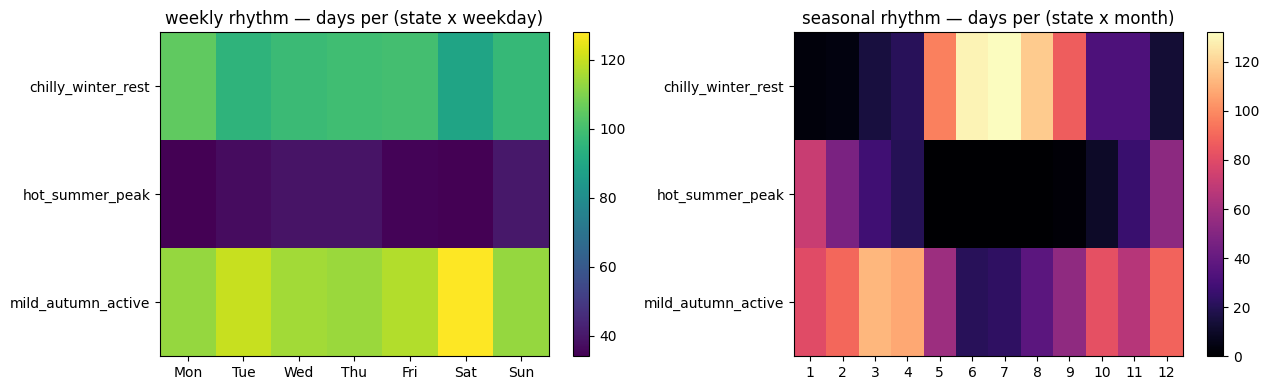

In [3]:
d = emb.copy()
d["dow"] = d["date"].dt.weekday
d["month"] = d["date"].dt.month
d["year"] = d["date"].dt.year

wk = d.groupby(["state_name", "dow"]).size().unstack(fill_value=0)
mo = d.groupby(["state_name", "month"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im0 = ax[0].imshow(wk.values, aspect="auto", cmap="viridis")
ax[0].set_yticks(range(len(wk.index))); ax[0].set_yticklabels(wk.index)
ax[0].set_xticks(range(7)); ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("weekly rhythm — days per (state x weekday)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(mo.values, aspect="auto", cmap="magma")
ax[1].set_yticks(range(len(mo.index))); ax[1].set_yticklabels(mo.index)
ax[1].set_xticks(range(mo.shape[1])); ax[1].set_xticklabels(list(mo.columns))
ax[1].set_title("seasonal rhythm — days per (state x month)"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

## 4. State transitions (Lifestyle KG) & drift over the years

top day-to-day transitions:
              from                 to  count
mild_autumn_active mild_autumn_active    557
chilly_winter_rest chilly_winter_rest    504
chilly_winter_rest mild_autumn_active    177
mild_autumn_active chilly_winter_rest    164
   hot_summer_peak    hot_summer_peak    158
mild_autumn_active    hot_summer_peak     99
   hot_summer_peak mild_autumn_active     85
   hot_summer_peak chilly_winter_rest     15
chilly_winter_rest    hot_summer_peak      1


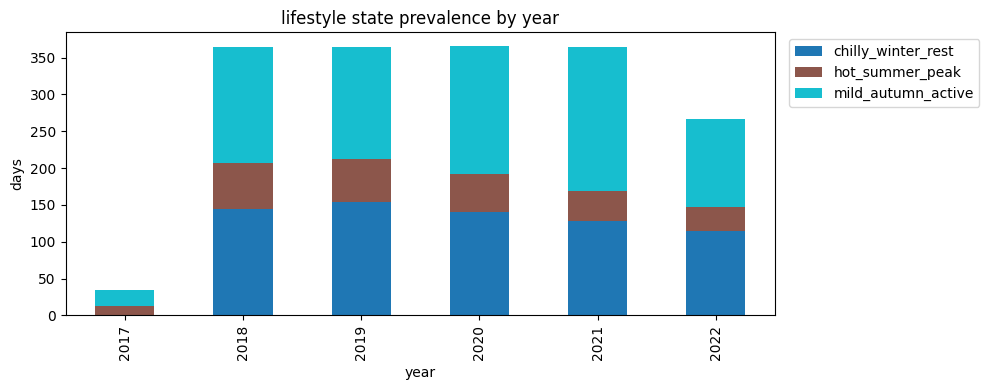

In [4]:
name_of = dict(zip(nodes["state"], nodes["name"]))
top = edges.head(10).copy()
top["from"] = top["src"].map(name_of)
top["to"] = top["dst"].map(name_of)
print("top day-to-day transitions:")
print(top[["from", "to", "count"]].to_string(index=False))

dr = d.groupby(["year", "state_name"]).size().unstack(fill_value=0)
dr.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="tab10")
plt.title("lifestyle state prevalence by year"); plt.ylabel("days")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()

## 5. Regime shifts — *when did this person's routine actually change?*

A **regime** = a sustained run of days in the same lifestyle state (≥5 days); a **break** = the
boundary between two regimes (brief 1–2 day flicker is merged away, so it is not mistaken for a shift).
For each break the **code measures** what changed — HR tone, temperature, wear time, workout frequency —
plus how unusual it is for *this* person: `p_transition` (how often this state-to-state move happens) and
`season_share` (how usual that state is in those calendar months; **below 15% = an off-season departure**).
The **LLM then writes one descriptive sentence** per shift from those measured numbers.

This is **lifestyle deviation, not anomaly detection** — it asks *when did this person's own routine
shift?*, never *is this person unwell?*.

In [5]:
import sys
LC_DIR = os.path.join(ROOT, "notebooks", "lifestyle_construction")
if LC_DIR not in sys.path:
    sys.path.insert(0, LC_DIR)
import lifestyle_construction as lc

ep_enr = pd.read_parquet(os.path.join(LR, "behavioral_episodes_enriched.parquet"))
days = lc.daily_summary(ep_enr).merge(emb[["date", "state_name"]], on="date", how="inner")
regimes = lc.segment_regimes(days, min_len=5)
breaks = lc.regime_breaks(regimes, days, top_k=6)

print(f"sustained regimes (>=5 days): {len(regimes)}   |   off-season departures among the "
      f"top {len(breaks)} shifts: {int(breaks['off_season'].sum())}")
cols = ["break_date", "from_state", "to_state", "days_before", "days_after",
        "p_transition", "season_share", "off_season", "d_mean_hr", "d_mean_temp",
        "d_wear_slots", "d_workout_frac"]
print(breaks[cols].to_string(index=False))

sustained regimes (>=5 days): 38   |   off-season departures among the top 6 shifts: 0
break_date         from_state           to_state  days_before  days_after  p_transition  season_share  off_season  d_mean_hr  d_mean_temp  d_wear_slots  d_workout_frac
2018-05-18    hot_summer_peak chilly_winter_rest            5         109         0.091         0.793       False        0.0        -16.6          10.5           0.009
2020-05-08 mild_autumn_active chilly_winter_rest           10         143         0.444         0.750       False       -1.1         -4.4           4.3          -0.023
2019-05-07 mild_autumn_active chilly_winter_rest           54         127         0.444         0.768       False        5.7         -7.1          -6.3          -0.580
2021-05-25 mild_autumn_active chilly_winter_rest           93         123         0.444         0.771       False       -0.5         -5.8           0.4          -0.005
2022-05-25 mild_autumn_active chilly_winter_rest          121         111

In [6]:
notes, note_src = lc.explain_breaks_llm(breaks, offline=False)
print(f"interpretation source: {note_src}\n")
for i, (_, r) in enumerate(breaks.iterrows()):
    print(f"[{r['break_date']}]  {notes[i]}\n")

interpretation source: llm

[2018-05-18]  The transition from hot summer to chilly winter involved a 16.6C temperature drop and a 10.5 slot increase in wear time, representing an unusual departure from the established pattern.

[2020-05-08]  Moving from mild autumn to chilly winter, the 1.1 bpm heart rate decrease and 4.4C temperature drop reflect an ordinary seasonal turn.

[2019-05-07]  The shift to chilly winter included a 5.7 bpm heart rate increase and a 0.58 decrease in workout frequency, marking an unusual departure from the pattern.

[2021-05-25]  This transition to chilly winter with a 0.5 bpm heart rate decrease and 5.8C temperature drop aligns with an ordinary seasonal turn.

[2022-05-25]  The shift to chilly winter featured a 1.6 bpm heart rate increase and a 10.0C temperature drop, which appears to be an ordinary seasonal turn.

[2019-12-15]  Transitioning from chilly winter to hot summer with an 8.2 bpm heart rate increase and 15.6C temperature rise represents an unusual 

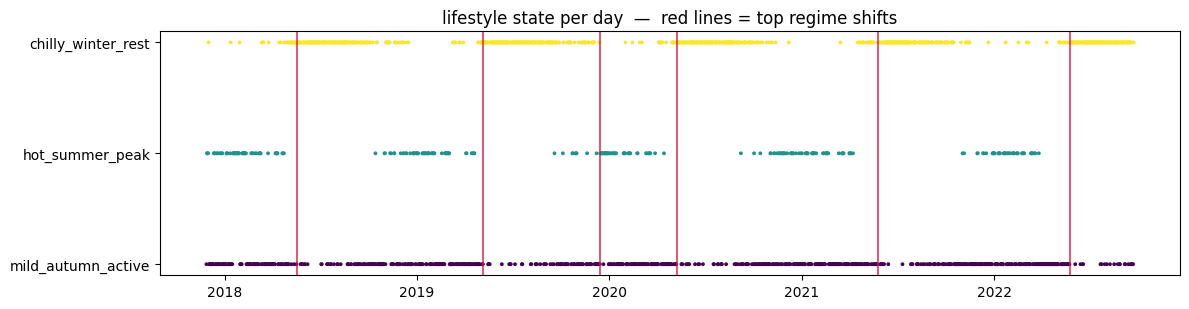

In [7]:
order = list(dict.fromkeys(emb.sort_values("date")["state_name"]))
ymap = {s: i for i, s in enumerate(order)}
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.scatter(emb["date"], emb["state_name"].map(ymap), s=3,
           c=emb["state_name"].map(ymap), cmap="viridis")
for _, r in breaks.iterrows():
    ax.axvline(pd.to_datetime(r["break_date"]), color="crimson", lw=1.2, alpha=0.85)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_title("lifestyle state per day  —  red lines = top regime shifts")
plt.tight_layout(); plt.show()

## 6. Honest validation (no lifestyle ground truth)

The clusters are validated against **derivable** structure never used as a target. `month`/`season`
and `workout_day` are clean proxies; `weekday` is *dependent* (time-of-day is available to the encoder).
AMI = adjusted mutual information.

In [8]:
cols = ["arm", "k", "silhouette", "month_ami", "season_ami", "workout_day_ami", "weekday_ami_DEPENDENT"]
print(evalp[cols].to_string(index=False))
print("\nCaveats: single seed; non-workout activity_context is an LLM *inference* (the enriched-vs-raw"
      " ablation shows it is a useful one, not noise); the aggregate baseline still wins workout_day"
      " (a rare-event axis); the measured 'help' is on the seasonal axis.")

                 arm  k  silhouette  month_ami  season_ami  workout_day_ami  weekday_ami_DEPENDENT
transformer_enriched  3      0.2870     0.1674      0.1915           0.0084                -0.0004
  aggregate_baseline  3         NaN     0.0278      0.0225           0.3167                 0.0105
     transformer_raw  3      0.2956     0.1172      0.1357           0.0516                 0.0017

Caveats: single seed; non-workout activity_context is an LLM *inference* (the enriched-vs-raw ablation shows it is a useful one, not noise); the aggregate baseline still wins workout_day (a rare-event axis); the measured 'help' is on the seasonal axis.


## 7. Narrative summary

In [9]:
sp = lmap.get("subject_priors", {})
dom = max(lmap["state_distribution"], key=lmap["state_distribution"].get)
print(f"Subject: age_band={sp.get('age_band','?')}, fitness={sp.get('fitness_level','?')}, "
      f"climate={sp.get('home_climate','?')}.")
print(f"Across {lmap['n_days']:,} days the dominant lifestyle state is '{dom}'.")
print("Days separate mainly by seasonal tone and resting-HR level; the device is worn predominantly on"
      " weekdays. The LLM-enriched embedding recovers this seasonal rhythm better than raw features or a"
      " trivial daily aggregate. This is a descriptive lifestyle portrait, not an anomaly/health verdict.")

Subject: age_band=40_49, fitness=recreational, climate=temperate.
Across 1,761 days the dominant lifestyle state is 'mild_autumn_active'.
Days separate mainly by seasonal tone and resting-HR level; the device is worn predominantly on weekdays. The LLM-enriched embedding recovers this seasonal rhythm better than raw features or a trivial daily aggregate. This is a descriptive lifestyle portrait, not an anomaly/health verdict.


## File 4 output summary

A descriptive lifestyle report rendered from File 3's artifacts — lifestyle states, weekly & seasonal
rhythm, day-to-day transitions, yearly drift, and the honest enriched-vs-raw-vs-baseline validation.
No ROC/PR/F1 anomaly audit (the professor's request). The old audit notebook is archived in
`notebooks/_archive/04_audit_metrics.ipynb`.